In [1]:
import numpy as np
import os
import random
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
import time
import torch, torchvision, pandas as pd, cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
print("GPU: ", torch.cuda.is_available())
import shutil

GPU:  False


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shlokraval/ppe-dataset-yolov8")
print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████| 2.35G/2.35G [09:41<00:00, 4.34MB/s]

Extracting files...


Path to dataset files: /Users/jeongjaehun/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1


In [4]:
shutil.move('/Users/jeongjaehun/.cache/kagglehub/datasets/shlokraval', 'dataset/')

'dataset/shlokraval'

In [5]:
ppe_detection = 'dataset/shlokraval/ppe-dataset-yolov8/versions/1'
print(os.listdir(ppe_detection))

['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'data.yaml', 'train']


In [6]:
with open(f"{ppe_detection}/data.yaml", 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 14
names: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']

roboflow:
  workspace: roboflow-universe-projects
  project: personal-protective-equipment-combined-model
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-universe-projects/personal-protective-equipment-combined-model/dataset/4


{'Fall-Detected': 3149, 'Person': 1034, 'Ladder': 734, 'NO-Hardhat': 9705, 'NO-Goggles': 2817, 'Hardhat': 28996, 'Gloves': 3381, 'NO-Gloves': 4280, 'Goggles': 2959, 'Safety Vest': 4499, 'Safety Cone': 9843, 'Mask': 1989, 'NO-Mask': 1577, 'NO-Safety Vest': 1435}


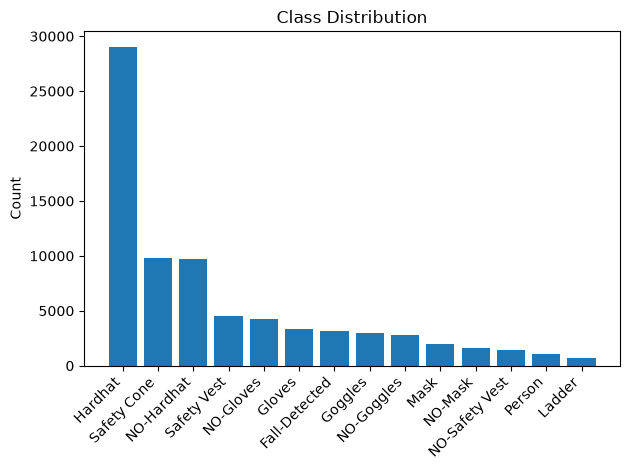

In [7]:
from collections import Counter

class_counts = Counter()
class_label = ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']

for file in os.listdir(ppe_detection + '/train/labels'):
    with open(os.path.join(ppe_detection + '/train/labels', file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

named_counts = {class_label[k]: v for k, v in class_counts.items()}
print(named_counts)

sorted_counts = dict(sorted(named_counts.items(), key=lambda x: x[1], reverse=True))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

In [8]:
print('train images', len(ppe_detection + 'train/images'))
print('valid images', len(ppe_detection + 'valid/images'))
print('test images', len(ppe_detection + 'test/images'))

train images 60
valid images 60
test images 59


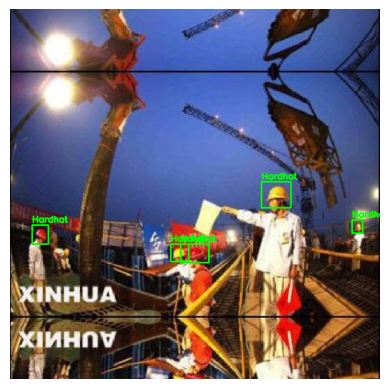

In [9]:
import random

def show_sample():
    file = random.choice(os.listdir(ppe_detection + '/train/labels'))

    img_path = os.path.join(ppe_detection + '/train/images', file.replace('.txt', '.jpg'))
    label_path = os.path.join(ppe_detection + '/train/labels', file)

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(label_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            label = class_label[int(cls)]

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Put label box
            cv2.putText(img, 
                        label, 
                        (x1, y1-5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 
                        0.5, 
                        (0, 255, 0), 
                        2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

show_sample()

In [11]:
count = 0
for file in os.listdir(ppe_detection + '/train/labels'):
    count += 1
    img_path = os.path.join(ppe_detection + '/train/images', file.replace('.txt', '.jpg'))
    if not os.path.exists(img_path):
        print(f'Missing image for: {file}')

print(count)

30765


In [13]:
current_dir = os.getcwd()

yolo_model = YOLO('yolov8n.pt')
start = time.time()
yolo_model.train(
    data=ppe_detection + '/data.yaml', 
    epochs=1, 
    imgsz=640, 
    batch=16, 
    project=os.path.join(current_dir, 'runs'), 
    name='ppe_yolo_results', 
    patience=10, 
    augment=True, 
    lr0=0.001, 
    save=True
)

elapsed_time = int(time.time() - start)
mins, secs = divmod(elapsed_time, 60)
print(f'{mins}:{secs}')

New https://pypi.org/project/ultralytics/8.4.110 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/shlokraval/ppe-dataset-yolov8/versions/1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=

In [15]:
yolo_trained_model = YOLO('runs/ppe_yolo_results/weights/best.pt')
val_metrics_yolo = yolo_trained_model.val(data=ppe_detection + '/data.yaml')

val_results_yolo = {
    "mAP@0.5": float(val_metrics_yolo.box.map50), 
    "map@0.5:0.95": float(val_metrics_yolo.box.map), 
    "Precision": float(val_metrics_yolo.box.mp), 
    "Recall": float(val_metrics_yolo.box.mr)
}
print(f"Validation Results for YOLO: {val_results_yolo}")

Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 254.1±7.3 MB/s, size: 57.7 KB)
val: Scanning /Users/jeongjaehun/Github/03_object_detection/dataset/shlokraval/ppe-dataset-yolov8/versions/1/valid/labels.cache... 8814 images, 210 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8814/8814 2.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 16% ━╸────────── 90/551 2.5s/it 2:41<19:30


KeyboardInterrupt: 

In [ ]:
test_metrics_yolo = yolo_trained_model.val(data=ppe_detection + '/data.yaml', split='test')

test_result_yolo = {
    "mAP@0.5": float(test_metrics_yolo.box.map50), 
    "mAP@0.5:0.95": float(test_metrics_yolo.box.map), 
    "Precision": float(test_metrics_yolo.box.mp), 
    "Recall": float(test_metrics_yolo.box.mr)
}
print(f"Test Results for YOLO: {test_result_yolo}")

In [ ]:
print(val_results_yolo.keys())
print(test_results_yolo.keys())

In [14]:
comparison_df = pd.DataFrame({
    "mAP@0.5": [val_results_yolo["mAP@0.5"], test_results_yolo["mAP@0.5"]], 
    "mAP@0.5:0.95": [val_results_yolo["mAP@0.5:0.95"]], 
    "Precision": [val_results_yolo["Precision"], test_results_yolo["Precision"]], 
    "Recall": [val_results_yolo["Recall"], test_results_yolo["Recall"]], 
    index=["Validation", "Test"]
})

print(comparison_df)
comparison_df.plot(kind="bar")
plt.title('Validation vs Test Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

NameError: name 'val_results_yolo' is not defined

In [ ]:
from IPython.display import Image, display

display(Image(filename=os.path.join('runs/ppe_yolo_results/train_batch2.jpg'), width=600))

In [ ]:
def predict_yolo(img_path):
    results = yolo_trained_model(img_path)
    results[0].show()

image_name = random.choice(os.listdir(ppe_detection + '/test/images'))
image_path = os.path.join(ppe_detection + '/test/images', image_name)
start = time.time()
predict_yolo(image_path)
rcnn_pred_time = time.time()

In [ ]:
def yolo_to_csv(split):
    image_dir = os.path.join(ppe_detection, split, 'images')
    label_dir = os.path.join(ppe_detection, split, 'labels')

    data = []

    for file in os.listdir(label_dir):
        label_path = os.path.join(label_dir, file)
        img_path = os.path.join(image_dir, file.replace('.txt', '.jpg'))

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        h, w, _ = img.shape
        if h == 0 or w == 0:
            continue

        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                data.append([img_path, x1, y1, x2, y2, int(cls)])

                df = pd.DataFrame(data, columns=[
                    'image_path', 'xmin', 'ymin', 'xmax', 'ymax', 'label'
                ])

                save_path = f'csv/{split}.csv'
                df.to_csv(save_path, index=False)

                print(f'{split}.csv created with {len(df)} annotations')
            
for split in ['train', 'valid', 'test']:
    yolo_to_csv(split)

In [ ]:
class Dataset(Dataset):
    def __init__(self, csv):
        self.df = pd.read_csv(csv)
        self.images = self.df['image_path'].unique()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        data = self.df[self.df['image_path'] == img_path]

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img = F.to_tensor(img)

        boxes = torch.tensor(data[['xmin', 'ymin', 'xmax', 'ymax']].values, dtype=torch.float32)
        labels = torch.tensor(data['label'].values, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels}
        return img, target

In [ ]:
def collate(x): return tuple(zip(*x))

train_loader = DataLoader(Dataset('csv/train.csv'), batch_size=4, shuffle=True, num_workers=2, collate_fn=collate)
val_loader = DataLoader(Dataset('csv/valid.csv'), batch_size=4, shuffle=False, num_workers=2, collate_fn=collate)
test_loader = DataLoader(Dataset('csv/test.csv'), batch_size=4, shuffle=False, num_workers=2, collate_fn=collate)